# Analysing Sentiment, Emotion, and Polarisation in Reddit Discussions on the Palestine-Israel Conflict Using Machine Learning

## Member 1: Data & Traditional ML Lead

This member focuses on dataset preparation, text preprocessing, TF-IDF feature extraction, traditional machine learning model training, and model evaluation.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/marshalanaazmanicloud.com/nltk_data...


True

## 2. Load Dataset

In [4]:
df = pd.read_csv("reddit_dataset.csv")

df.head()

,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,onkan89,1,That's just Palestine's history lol,IsraelPalestine,2026-05-24 07:15:09,1tlvu9b,Late_Ad2203,0,1,0,...,206.0,19329.0,19535.0,78,"From what I can tell, the incident took placed...",Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20
1,onkalu2,1,Just going to leave this here. Israel are defe...,IsraelPalestine,2026-05-24 07:14:48,1tlvu9b,Late_Ad2203,0,1,0,...,206.0,19329.0,19535.0,78,"From what I can tell, the incident took placed...",Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20
2,onkakbn,1,What kind of physical evidence would it leave ...,IsraelPalestine,2026-05-24 07:14:26,1tkmfii,OneReportersOpinion,0,1,0,...,46382.0,283342.0,329724.0,18,Re: the Kristoff piece on Israeli prison rape....,More thoughts on the Kristof opinion editorial,0.74,18,0,2026-05-22 15:31:32
3,onka939,1,I mean... you mention that this documentation ...,IsraelPalestine,2026-05-24 07:11:45,1tlx2k8,warsage,0,1,0,...,2105.0,86167.0,88272.0,0,The goal of this post is to document sexual as...,An investigation into sexual assault in the Is...,0.50,0,0,2026-05-24 00:37:21
4,onka51q,1,An airport is not the best place to cause trou...,worldnews,2026-05-24 07:10:46,1tllkrd,Efficient-Wolf7068,0,1,0,...,1.0,3103.0,3104.0,2540,NaN,Clashes in Spain: Gaza flotilla activists beat...,0.87,2540,0,2026-05-23 16:47:24


## 3. Dataset Overview

In [5]:
df.shape

(354299, 24)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 354299 entries, 0 to 354298
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   comment_id                  354299 non-null  str    
 1   score                       354299 non-null  int64  
 2   self_text                   354298 non-null  str    
 3   subreddit                   354299 non-null  str    
 4   created_time                354299 non-null  str    
 5   post_id                     354299 non-null  str    
 6   author_name                 354299 non-null  str    
 7   controversiality            354299 non-null  int64  
 8   ups                         354299 non-null  int64  
 9   downs                       354299 non-null  int64  
 10  user_is_verified            354299 non-null  bool   
 11  user_account_created_time   348951 non-null  str    
 12  user_awardee_karma          354247 non-null  float64
 13  user_awarder_karma       

In [7]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time'],
      dtype='str')

In [8]:
df.isnull().sum()

comment_id                         0
score                              0
self_text                          1
subreddit                          0
created_time                       0
post_id                            0
author_name                        0
controversiality                   0
ups                                0
downs                              0
user_is_verified                   0
user_account_created_time       5348
user_awardee_karma                52
user_awarder_karma                52
user_link_karma                   52
user_comment_karma                52
user_total_karma                  52
post_score                         0
post_self_text                192422
post_title                         0
post_upvote_ratio                  0
post_thumbs_ups                    0
post_total_awards_received         0
post_created_time                  0
dtype: int64

In [9]:
df.duplicated().sum()

0

## 4. Exploratory Data Analysis (EDA)

#### EDA 1: Dataset Size

In [52]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 353472
Number of columns: 29


#### EDA 2: Missing Values

In [53]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

post_self_text               191968
user_account_created_time      5335
user_link_karma                  52
user_comment_karma               52
user_awarder_karma               52
user_awardee_karma               52
user_total_karma                 52
self_text                         1
dtype: int64

#### EDA 3: Duplicate Rows

In [54]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


#### EDA 4: Subreddit Distribution

In [55]:
df["subreddit"].value_counts().head(10)

subreddit
IsraelPalestine       106507
worldnews             103112
PublicFreakout         55410
Palestine              33190
CombatFootage          21228
AskMiddleEast          12692
NonCredibleDefense      7466
CrazyFuckingVideos      5872
worldnewsvideo          4637
NoahGetTheBoat          1535
Name: count, dtype: int64

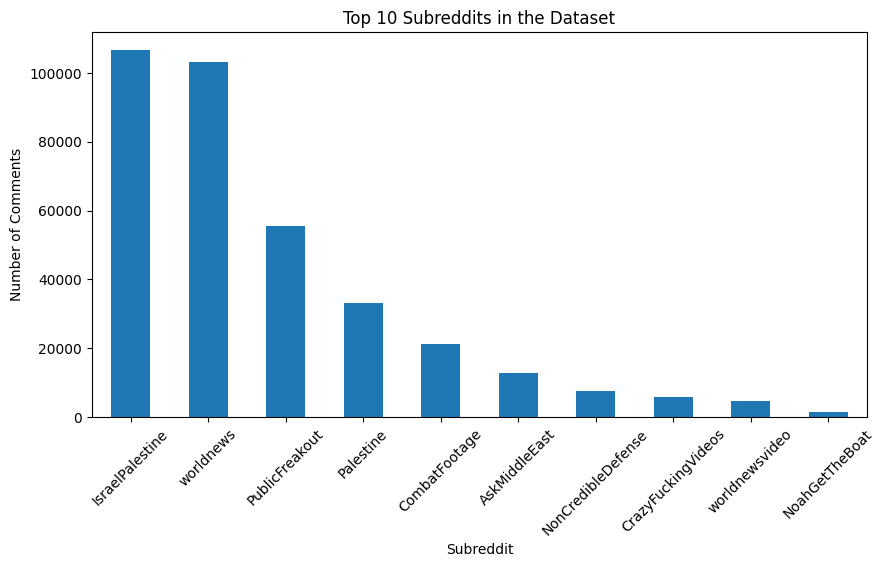

In [56]:
plt.figure(figsize=(10,5))
df["subreddit"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Subreddits in the Dataset")
plt.xlabel("Subreddit")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

#### EDA 5: Text Length Analysis

In [57]:
df["text_length"] = df["self_text"].fillna("").astype(str).apply(len)
df["word_count"] = df["self_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

In [58]:
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,353472.000000,353472.000000
mean,234.428014,39.098675
std,391.569613,62.817871
min,0.000000,0.000000
25%,54.000000,9.000000
50%,115.000000,20.000000
75%,254.000000,43.000000
max,9929.000000,1653.000000


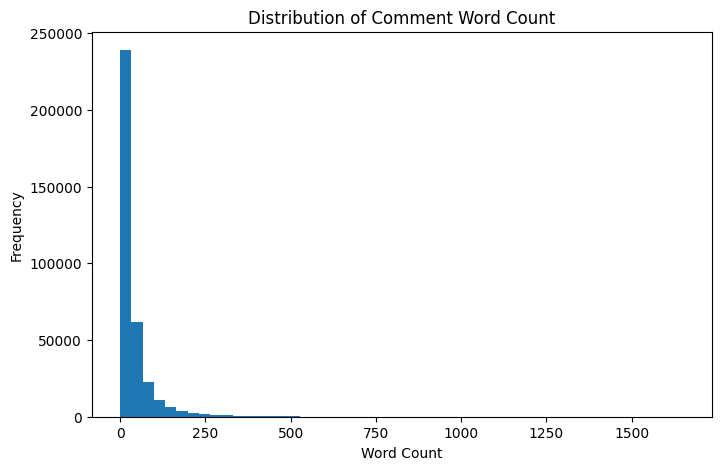

In [59]:
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### EDA 6: Engagement Features

In [60]:
df[["score", "ups", "downs", "controversiality"]].describe()

,score,ups,downs,controversiality
count,353472.000000,353472.000000,353472.0,353472.000000
mean,29.743468,29.743468,0.0,0.076167
std,248.091525,248.091525,0.0,0.265266
min,-549.000000,-549.000000,0.0,0.000000
25%,1.000000,1.000000,0.0,0.000000
50%,3.000000,3.000000,0.0,0.000000
75%,11.000000,11.000000,0.0,0.000000
max,31613.000000,31613.000000,0.0,1.000000


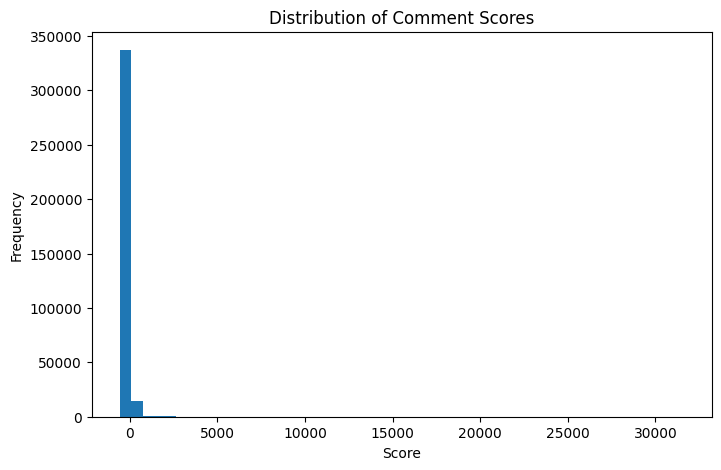

In [61]:
plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=50)
plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [62]:
df["controversiality"].value_counts()

controversiality
0    326549
1     26923
Name: count, dtype: int64

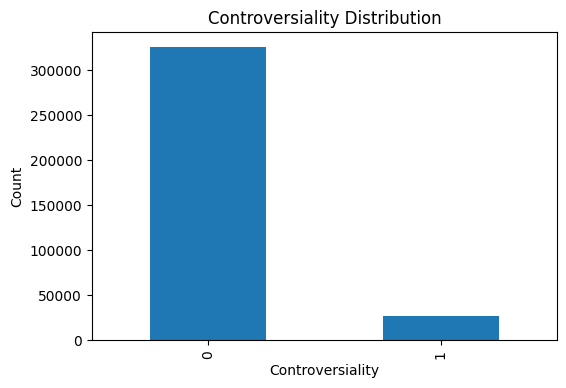

In [63]:
plt.figure(figsize=(6,4))
df["controversiality"].value_counts().plot(kind="bar")
plt.title("Controversiality Distribution")
plt.xlabel("Controversiality")
plt.ylabel("Count")
plt.show()

#### EDA 7: Time-based Analysis

In [64]:
df["created_time"] = pd.to_datetime(df["created_time"], errors="coerce")
df["date"] = df["created_time"].dt.date

In [65]:
comments_by_date = df.groupby("date").size()

comments_by_date.head()

date
2026-01-01    1250
2026-01-02    1503
2026-01-03    1574
2026-01-04    1814
2026-01-05    1934
dtype: int64

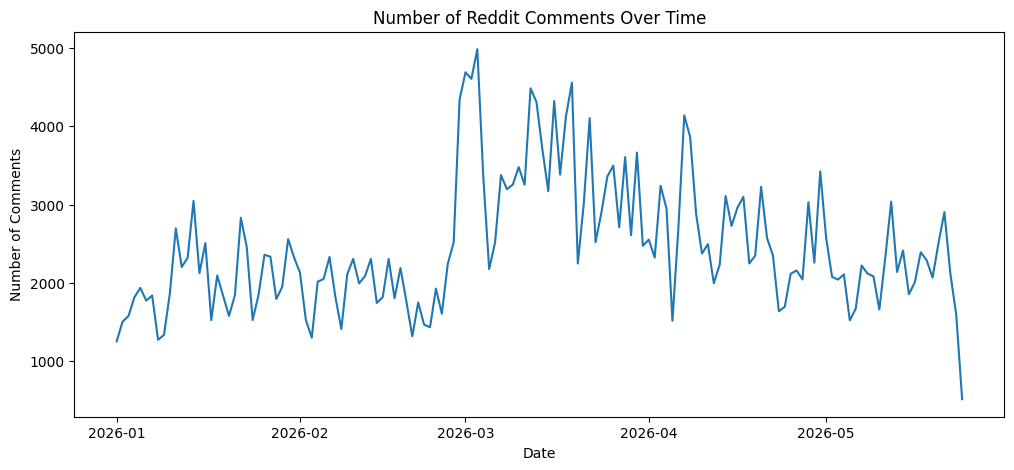

In [66]:
plt.figure(figsize=(12,5))
comments_by_date.plot()
plt.title("Number of Reddit Comments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")
plt.show()

## 5. Select Text Column

In [10]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time'],
      dtype='str')

In [12]:
df["combined_text"] = (
    df["post_title"].fillna("") + " " +
    df["self_text"].fillna("")
)

text_column = "combined_text"

df[[text_column]].head()

,combined_text
0,Gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...
3,An investigation into sexual assault in the Is...
4,Clashes in Spain: Gaza flotilla activists beat...


In [13]:
df[text_column].isnull().sum()

0

In [14]:
df[text_column].head(10)

0    Gaza floatila activists beaten up and detained...
1    Gaza floatila activists beaten up and detained...
2    More thoughts on the Kristof opinion editorial...
3    An investigation into sexual assault in the Is...
4    Clashes in Spain: Gaza flotilla activists beat...
5    TRT World - France bans Israel's Ben-Gvir over...
6    Israel intercepts the Gaza flotilla and deport...
7    I'm the only Pro-Israel student in my universi...
8    Israel intercepts the Gaza flotilla and deport...
9    I'm the only Pro-Israel student in my universi...
Name: combined_text, dtype: str

## 6. Remove Missing and Duplicate Text

In [15]:
df = df[df[text_column].astype(str).str.strip() != ""]

In [16]:
df = df.drop_duplicates(subset=[text_column])

In [17]:
df.shape

(353472, 25)

## 7. Data Cleaning

In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [19]:
df["clean_text"] = df[text_column].apply(clean_text)

df[[text_column, "clean_text"]].head()

,combined_text,clean_text
0,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...,more thoughts on the kristof opinion editorial...
3,An investigation into sexual assault in the Is...,an investigation into sexual assault in the is...
4,Clashes in Spain: Gaza flotilla activists beat...,clashes in spain gaza flotilla activists beate...


## 8. Text Preprocessing

In [20]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [21]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [22]:
df["processed_text"] = df["clean_text"].apply(preprocess_text)

df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
1,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
2,more thoughts on the kristof opinion editorial...,thought kristof opinion editorial kind physica...
3,an investigation into sexual assault in the is...,investigation sexual assault israelpalestine c...
4,clashes in spain gaza flotilla activists beate...,clash spain gaza flotilla activist beaten poli...


## 9. Sentiment Label Preparation

In [23]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [24]:
df["compound"] = df["processed_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [25]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [26]:
df["sentiment"] = df["compound"].apply(label_sentiment)

target_column = "sentiment"

df["sentiment"].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

## 10. Check Class Distribution

In [27]:
df[target_column].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

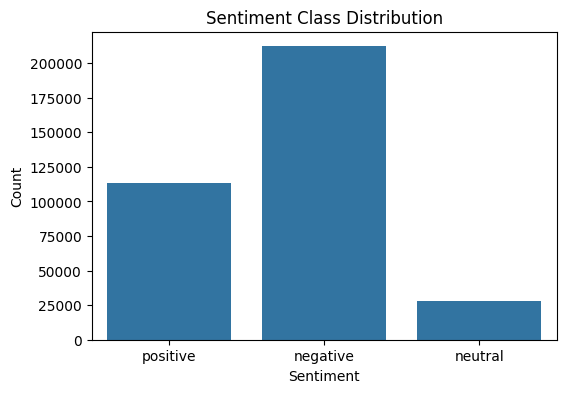

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_column)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 11. Train-Test Split

In [30]:
X_text = df["processed_text"]
y = df[target_column]

In [31]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Training size:", X_train_text.shape)
print("Testing size:", X_test_text.shape)

Training size: (282777,)
Testing size: (70695,)


## 12. TF-IDF Feature Extraction

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [34]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [35]:
print("TF-IDF training shape:", X_train.shape)
print("TF-IDF testing shape:", X_test.shape)

TF-IDF training shape: (282777, 5000)
TF-IDF testing shape: (70695, 5000)


## 13. Logistic Regression Model

Logistic Regression is trained as one of the traditional machine learning models for sentiment classification.

In [36]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [37]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8719994341891223
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91     42425
     neutral       0.83      0.63      0.71      5624
    positive       0.85      0.83      0.84     22646

    accuracy                           0.87     70695
   macro avg       0.85      0.79      0.82     70695
weighted avg       0.87      0.87      0.87     70695



## 14. Naive Bayes Model

Naive Bayes is trained as a baseline model because it is commonly used for text classification tasks.

In [38]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [39]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7310276540066483
              precision    recall  f1-score   support

    negative       0.73      0.92      0.82     42425
     neutral       0.50      0.15      0.23      5624
    positive       0.75      0.52      0.61     22646

    accuracy                           0.73     70695
   macro avg       0.66      0.53      0.55     70695
weighted avg       0.72      0.73      0.70     70695



## 15. Support Vector Machine Model

Support Vector Machine is trained using LinearSVC because it works well with high-dimensional TF-IDF text features.

In [41]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [42]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8690713628969517
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91     42425
     neutral       0.83      0.59      0.69      5624
    positive       0.84      0.83      0.84     22646

    accuracy                           0.87     70695
   macro avg       0.85      0.78      0.81     70695
weighted avg       0.87      0.87      0.87     70695



## 16. Confusion Matrix

In [43]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred
}

labels = sorted(y.unique())

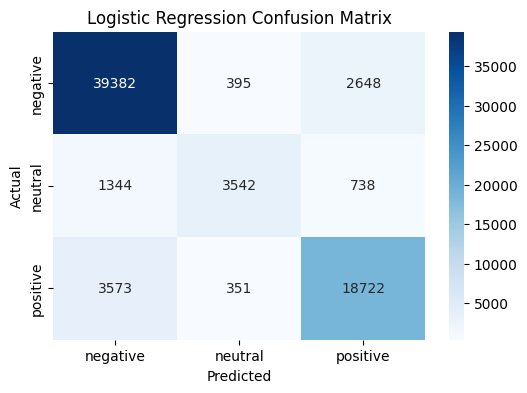

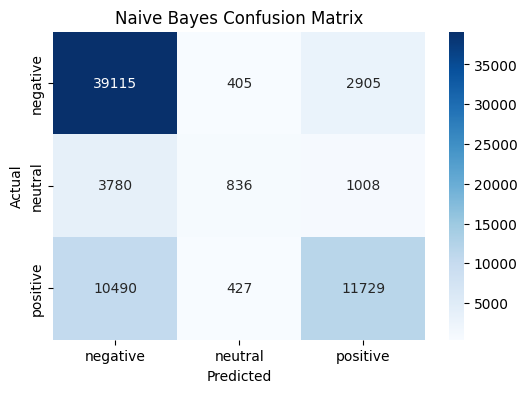

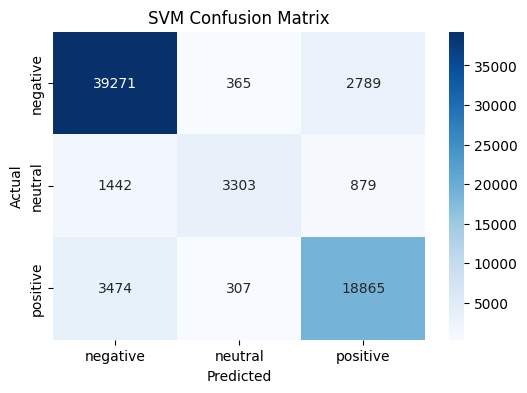

In [44]:
for name, pred in models.items():
    cm = confusion_matrix(y_test, pred, labels=labels)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 17. Model Comparison

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    
    "Precision (Macro)": [
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, nb_pred, average="macro"),
        precision_score(y_test, svm_pred, average="macro")
    ],
    
    "Recall (Macro)": [
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, nb_pred, average="macro"),
        recall_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Macro)": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, nb_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Weighted)": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),F1-score (Weighted)
0,Logistic Regression,0.871999,0.853958,0.794933,0.819855,0.869899
1,Naive Bayes,0.731028,0.661245,0.529519,0.552826,0.704500
2,SVM,0.869071,0.852302,0.782000,0.810048,0.866464


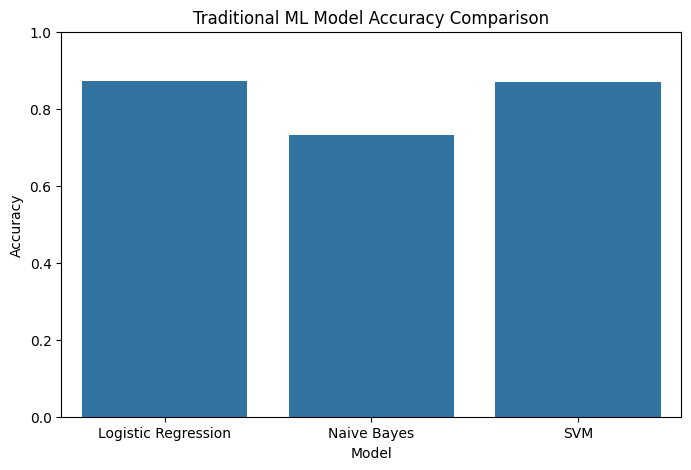

In [51]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Traditional ML Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

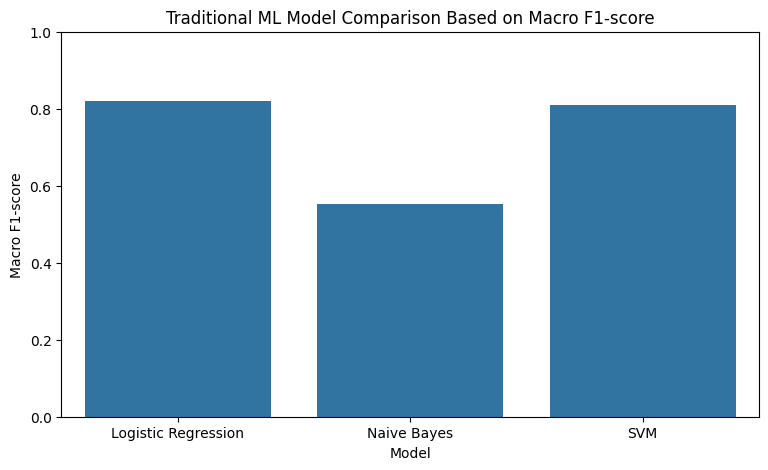

In [50]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="F1-score (Macro)")
plt.title("Traditional ML Model Comparison Based on Macro F1-score")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.show()

## 18. Save Output

The cleaned dataset and model comparison results are saved for report writing, presentation, and future integration with other group members.

In [47]:
df.to_csv("cleaned_reddit_sentiment_dataset.csv", index=False)
results.to_csv("traditional_ml_model_results.csv", index=False)

Since the dataset did not contain predefined sentiment labels, VADER was used to generate initial sentiment classes based on compound sentiment scores. These generated labels were then used as the target variable for training traditional machine learning models.